In [1]:
import torch
import torch.nn as nn
import nibabel as nib
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader

# --- 1. Data Ingestion & Formatting ---
DATA_PATH = "/mnt/storage/rsa_projects/bayesian_rsa/brain_data/sub-NDARINVZT44Y065_filtered_func_data.nii.gz"
BATCH_SIZE = 64
EPOCHS = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_fmri_data(file_path):
    print("Loading fMRI data...")
    img = nib.load(file_path)
    data = img.get_fdata()
    data = np.nan_to_num(data)
    data = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8)
    return data 

# Slices the 4D brain volume into individual 2D images for the model
class FMRISliceDataset(Dataset):
    def __init__(self, data_4d):
        self.data = data_4d
        X, Y, Z, T = data_4d.shape
        self.slices = []
        for z in range(Z):
            for t in range(T):
                sl = data_4d[:, :, z, t]
                if (sl > 1e-6).mean() > 0.01: 
                    self.slices.append((z, t))
        random.shuffle(self.slices)

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        z, t = self.slices[idx]
        sl = self.data[:, :, z, t].astype(np.float32)
        # Add channel dimension to match PyTorch requirement -> (1, 90, 90)
        return torch.tensor(sl).unsqueeze(0) 

# --- 2. VAE Architecture ---
class BrainVAE(nn.Module):
    def __init__(self):
        super(BrainVAE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )
        # Latent Space
        self.fc_mu = nn.Linear(32 * 23 * 23, 128)
        self.fc_logvar = nn.Linear(32 * 23 * 23, 128)
        
        # Decoder
        self.decoder_input = nn.Linear(128, 32 * 23 * 23)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        original_shape = x.shape
        
        # Encode
        h = self.encoder(x)
        h = torch.flatten(h, start_dim=1)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        
        # Decode
        dec_in = self.decoder_input(z)
        dec_in = dec_in.view(-1, 32, 23, 23)
        out = self.decoder(dec_in)
        
      
        out = out[:, :, :original_shape[2], :original_shape[3]]
        
        return out, mu, logvar

# --- 3. Loss Function ---
def vae_loss(recon_x, x, mu, logvar):
    # Binary Cross Entropy works here because the data is scaled [0, 1]
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + (0.0001 * KLD)

# --- 4. Training Loop ---
if __name__ == "__main__":
    print(f"Device: {device}")
    
    # 1. Load Data
    raw_data = load_fmri_data(DATA_PATH)
    dataset = FMRISliceDataset(raw_data)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    print(f"Extracted {len(dataset)} valid brain slices for training.")
    
    # 2. Init Model
    model = BrainVAE().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # 3. Train
    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0
        
        for batch in dataloader:
            batch = batch.to(device)
            optimizer.zero_grad()
            
            recon_batch, mu, logvar = model(batch)
            loss = vae_loss(recon_batch, batch, mu, logvar)
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(dataset)
        print(f"Epoch [{epoch:02d}/{EPOCHS}] | Average Loss: {avg_loss:.4f}")

Device: cuda
Loading fMRI data...
Extracted 26220 valid brain slices for training.
Epoch [01/100] | Average Loss: 4373.0165
Epoch [02/100] | Average Loss: 4331.9814


KeyboardInterrupt: 

Generating brain images...


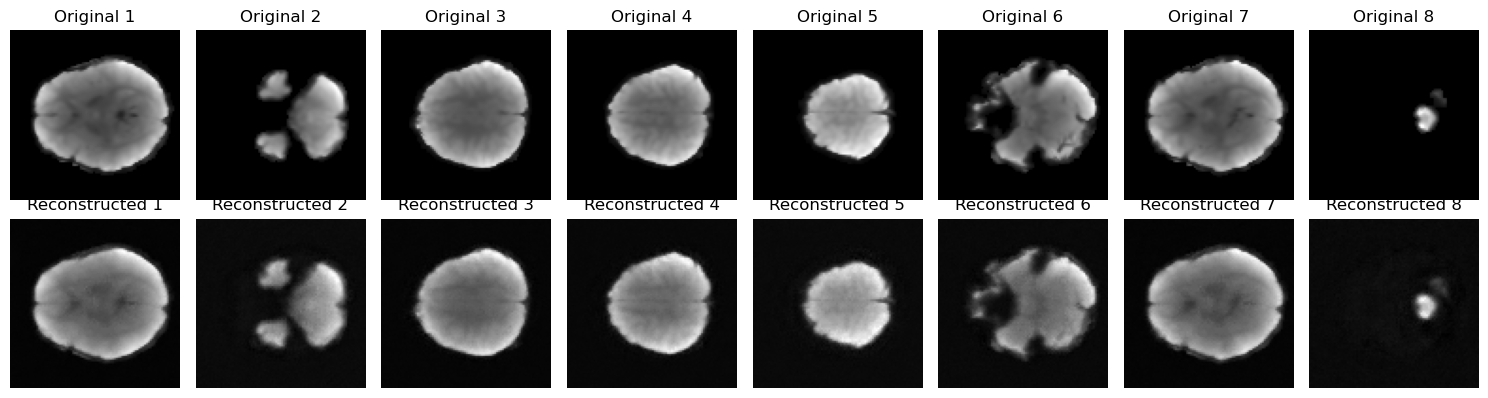

In [2]:
import matplotlib.pyplot as plt

print("Generating brain images...")


model.eval()


with torch.no_grad():
    real_batch = next(iter(dataloader)).to(device)
    
 
    recon_batch, _, _ = model(real_batch)


n_samples = min(8, real_batch.size(0))
fig, axes = plt.subplots(2, n_samples, figsize=(15, 4))

for i in range(n_samples):
    
    axes[0, i].imshow(real_batch[i, 0].cpu().numpy(), cmap='gray')
    axes[0, i].set_title(f'Original {i+1}')
    axes[0, i].axis('off')

    
    axes[1, i].imshow(recon_batch[i, 0].cpu().numpy(), cmap='gray')
    axes[1, i].set_title(f'Reconstructed {i+1}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()